In [2]:
# I would play a bit with the concept of value, simple and continously compound return and how they stack up
# together over a stock index such as the S&P 500

# load all required folders
import numpy as np
import pandas as pd
import scipy.optimize as optimize
from matplotlib import pyplot as plt

import sys
import os
sys.path.append(os.path.abspath("../"))

from src.utils import *

In [3]:
# load the overall S&P 500 values over the last year

snp500_all_year_values = get_snp_500_values('1y')

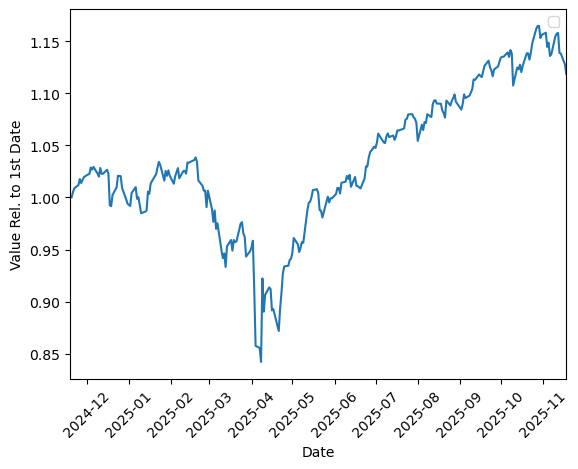

In [4]:
# change to % by dividing by the first value and mult by 100

snp500_all_year_normalized = snp500_all_year_values.copy()

snp500_all_year_normalized.iloc[:] = snp500_all_year_normalized.iloc[:] / snp500_all_year_values.iloc[0]

# plot the values over the year
x, y = snp500_all_year_normalized.index.to_numpy(), snp500_all_year_normalized['^GSPC'].to_numpy()
fig, ax = plt.subplots()
ax.plot(x, y)
ax.set_xlabel('Date')
ax.set_ylabel('Value Rel. to 1st Date')
ax.set_xlim([snp500_all_year_normalized.index[0], snp500_all_year_normalized.index[-1]])
ax.legend([])
plt.xticks(rotation=45)
plt.show()
plt.close()

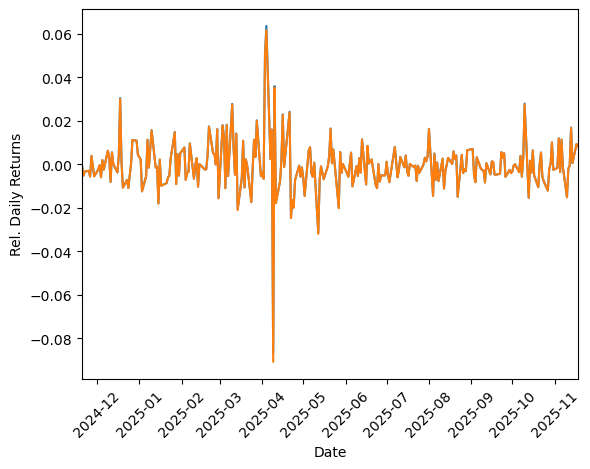

Avg. Abs. Rel. Diff: 0.003673682428703653


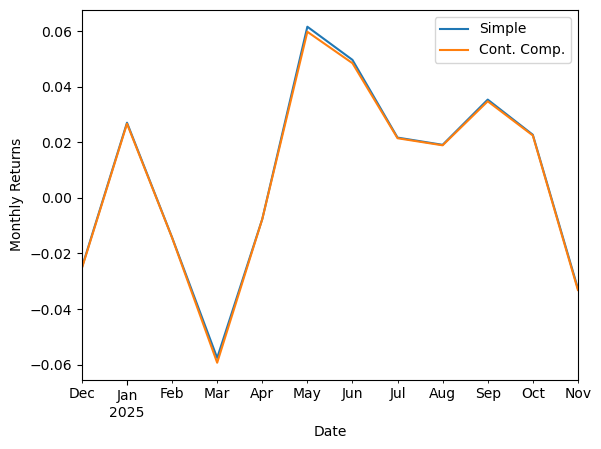

Avg. Abs. Rel. Diff: 0.01555061089024293


In [5]:
# plot the daily simple and continously compound returns on the same figure, see if they're approx the same

fig, ax = plt.subplots()

simple_return = (y[:-1]-y[1:])/y[1:]
cont_compound_return = np.log(y[:-1]/y[1:])

ax.plot(x[1:], simple_return, label='Simple')
ax.plot(x[1:], cont_compound_return, label='Cont. Compound')
ax.set_xlabel('Date')
ax.set_ylabel('Rel. Daily Returns')
ax.set_xlim([x[1], x[-1]])
plt.xticks(rotation=45)
plt.show()
plt.close()

# print how well the simple return predicts the more mathematically robust cont. compound one in the daily scale
print("Avg. Abs. Rel. Diff:", np.abs((cont_compound_return-simple_return)/cont_compound_return).mean())

# do same for monthly

monthly_simple_returns = snp500_all_year_normalized.resample('ME').last().pct_change().iloc[1:]
monthly_simple_returns.rename(columns={'^GSPC': 'Simple'}, inplace=True)
monthly_cont_compount_returns = snp500_all_year_normalized.resample('ME').last().apply(lambda x: np.log(x)).diff().iloc[1:]
monthly_cont_compount_returns.rename(columns={'^GSPC': 'Cont. Comp.'}, inplace=True)
monthly_returns = pd.concat([monthly_simple_returns, monthly_cont_compount_returns], axis=1)
monthly_returns.columns.name = None

monthly_returns.plot()
plt.ylabel('Monthly Returns')
plt.show()

print("Avg. Abs. Rel. Diff:", np.abs(((monthly_returns['Simple'] - monthly_returns['Cont. Comp.'])/monthly_returns['Cont. Comp.']).to_numpy()).mean())

In [6]:
# check how close the cont. compound and simple returns are when aggregated over an year (i.e. how much assuming that simple returns may be sum up is wrong)


print("Agg. Cont. Comp. Ret. over 1y:", cont_compound_return.sum(), "Agg. Simp. Ret. over 1y:", simple_return.sum())

# Result: Agg. Cont. Comp. Ret. over 1y: -0.12411070764897074 Agg. Simp. Ret. over 1y: -0.10676472572298668 
# Interpretation: on this scale the aggreagration is quite wrong (>15%) while the average daily error is about 0.004
# we should note that the error is always directed due to the nature of the simple return being a first order taylor approx of cont. comp. return.

Agg. Cont. Comp. Ret. over 1y: -0.11186424728420473 Agg. Simp. Ret. over 1y: -0.0944916159226954


Mean: 0.0004602970801205139 Var: 0.00013183745564838504 Skwedness: -0.6757168800670837 Kurtosis: 16.377534564796342


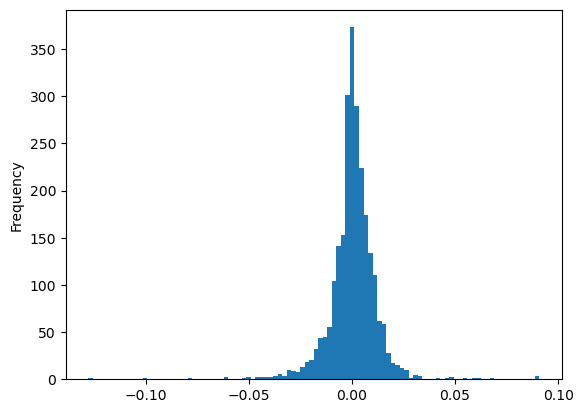

In [ ]:
# find the distribution on returns in the last 10 years

# get the values over the last 10 years
snp500_all_year_values = get_snp_500_values('10y')
# calculate cont. comp. ret.
rets = snp500_all_year_values['^GSPC'].apply(lambda x: np.log(x)).diff()[1:]
# plot
rets.plot.hist(bins=100)
# print moments (up to some square)
print("Mean:", rets.mean(), "Var:", rets.var(), "Skwedness:", rets.skew(), "Kurtosis:", rets.kurt())

# TODO: play with statistical tests a bit for refreshing knowledge about it


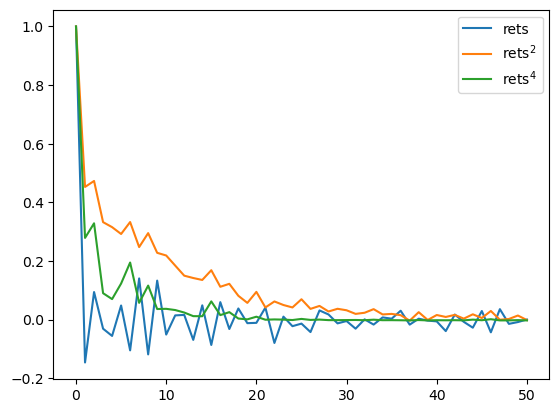

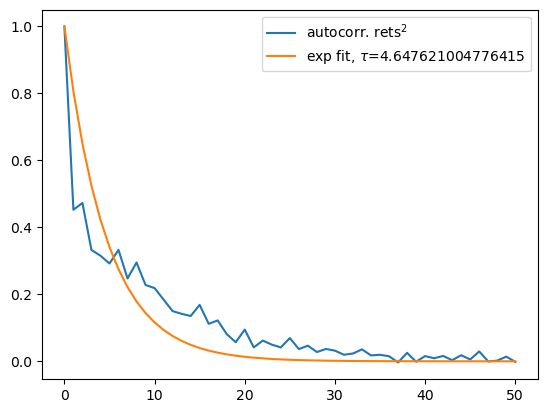

/tmp/ipykernel_4052/1741054850.py:31: RuntimeWarning: invalid value encountered in log
  plt.plot(days, -np.log(rets_2_autocorr_up_to_50_lags))


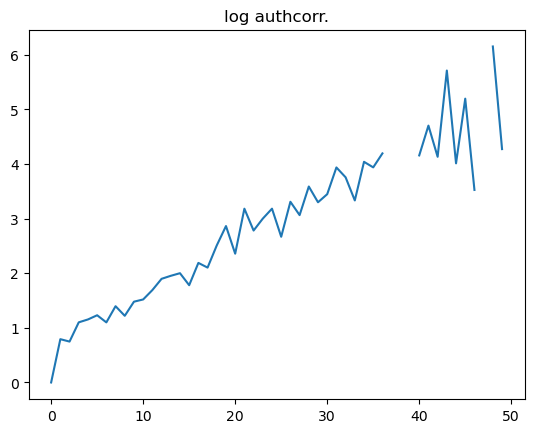

/tmp/ipykernel_4052/1741054850.py:42: RuntimeWarning: invalid value encountered in log
  plt.plot(days, -np.log(rets_2_autocorr_up_to_50_lags), label=r"log(autocorr. rets$^2)$")


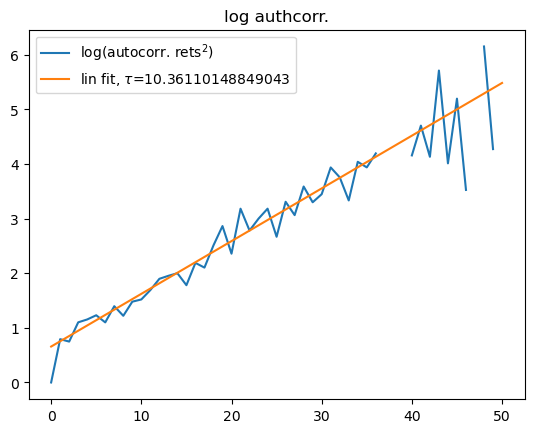

In [18]:
# check the autocorrelation of rets, rets^2 and rets^4
rets_autocorr_up_to_50_lags = [rets.autocorr(lag = n) for n in range(51)]

rets_2 = rets.apply(lambda x: x*x)
rets_4 = rets_2.apply(lambda x: x*x)

rets_2_autocorr_up_to_50_lags = [rets_2.autocorr(lag = n) for n in range(51)]
rets_4_autocorr_up_to_50_lags = [rets_4.autocorr(lag = n) for n in range(51)]

plt.plot(rets_autocorr_up_to_50_lags, label=r"rets")
plt.plot(rets_2_autocorr_up_to_50_lags, label=r"rets$^2$")
plt.plot(rets_4_autocorr_up_to_50_lags, label=r"rets$^4$")
plt.legend()
plt.show()
plt.close()

# it seems that only rets^2 has decent correlation, try to fit it to exp to estimate life-time.
exp_fit = lambda x, tau : np.exp(-x/tau)
days = np.linspace(0.0, 50.0, 51, endpoint=True)
tau = optimize.curve_fit(exp_fit, days, rets_2_autocorr_up_to_50_lags, [1.0], bounds=[0.0001, 100.0])[0][0]

# plot rets_2 and the correlation time
plt.plot(days, rets_2_autocorr_up_to_50_lags, label=r"autocorr. rets$^2$")
plt.plot(days, exp_fit(days, tau), label=r"exp fit, $\tau$={}".format(tau))
plt.legend()
plt.show()
plt.close()

# as one might see, the fit is terrible, try a log plot

plt.plot(days, -np.log(rets_2_autocorr_up_to_50_lags))
plt.title("log authcorr.")
plt.show()
plt.close()

# this one looks better, lets fit it to linear to get the decay rate after the first dip
lin_fit = lambda x, tau, c : x/tau + c
tau, c = optimize.curve_fit(lin_fit, days[1:31], -np.log(rets_2_autocorr_up_to_50_lags[1:31]), [1.0, 0.0], bounds=[[0.0, -10.0],[100.0, 10.0]])[0]

# plot the fit 

plt.plot(days, -np.log(rets_2_autocorr_up_to_50_lags), label=r"log(autocorr. rets$^2)$")
plt.plot(days, lin_fit(days, tau, c), label=r"lin fit, $\tau$={}".format(tau))
plt.title("log authcorr.")
plt.legend()
plt.show()
plt.close()